## Dice-Sorensen-Koef

Der Dice-Koeffizient (DSC) misst, wie ähnlich zwei Bereiche (oder Segmentierungen) in einem Bild sind. Man kann ihn sich vorstellen als:

$$ DSC = \frac{2|A \cap B|}{|A| + |B|} $$

wobei,
- $A$ die Menge der Pixel im ersten Segmentierungsergebnis
- $|A|$ die Anzahl der Elemente (Pixel) in Menge $A$ ist.


In [4]:
%pip install -q pillow

In [5]:
from PIL import Image
import numpy as np
from skimage.transform import resize
import os

def load_and_preprocess_image_tif(image_path, mask_path, target_size=(256, 256)):
    """
    Diese Funktion lädt und skaliert Bilder und Masken im TIFF-Format auf eine einheitliche Größe.
    """
    # Lade das Bild im TIFF-Format
    image = Image.open(image_path)
    mask = Image.open(mask_path)   # Lade die zugehörige Maske
    # Konvertiere die PIL-Bilder in NumPy-Arrays
    image_array = np.array(image)
    mask_array = np.array(mask)
    # Skaliere die Bilder und Masken auf die Zielgröße
    image_resized = resize(image_array, target_size, mode='constant', preserve_range=True)
    mask_resized = resize(mask_array, target_size, mode='constant', preserve_range=True)
    # Normalisiere das Bild
    image_normalized = image_resized / 255.0
    mask_normalized = mask_resized / 255.0
    mask_binary = np.round(mask_normalized)  # Binär-Maske
    return image_normalized, mask_binary

train_images = []
train_masks = []
train_dir = '/content/train'

# Laden der TIFF-Bilder und Masken
for file_name in os.listdir(train_dir):
    if file_name.endswith('.tif') and '_mask' not in file_name:
        image_path = os.path.join(train_dir, file_name)
        mask_path = image_path.replace('.tif', '_mask.tif')
        image, mask = load_and_preprocess_image_tif(image_path, mask_path)
        train_images.append(image)
        train_masks.append(mask)

train_images = np.array(train_images)
train_masks = np.array(train_masks)

In [6]:
print(len(train_images) + len(train_masks) == 74)

True


In [7]:
# Überprüfe die Dimensionen der Arrays
train_masks = np.expand_dims(train_masks, axis=-1)  # Füge eine neue Dimension für die Masken hinzu

print(train_images.shape)
print(train_masks.shape)

(37, 256, 256, 3)
(37, 256, 256, 1)


In [25]:
additional_images = []
additional_masks = []
additional_dir = '/content/add'

for file_name in os.listdir(additional_dir):
    if file_name.endswith('.tif') and '_mask' not in file_name:
        image_path = os.path.join(additional_dir, file_name)
        mask_path = image_path.replace('.tif', '_mask.tif')
        image, mask = load_and_preprocess_image_tif(image_path, mask_path)
        additional_images.append(image)
        additional_masks.append(mask)

additional_images = np.array(additional_images)
additional_masks = np.array(additional_masks)

In [26]:
print(additional_images.shape)
print(additional_masks.shape)

(85, 256, 256, 4)
(85, 256, 256)


In [27]:
additional_images_rgb = additional_images[:, :, :, :3] # Selektiert die ersten 3 Kanälen
additional_masks = np.expand_dims(additional_masks, axis=-1)

In [28]:
print(additional_images_rgb.shape)
print(additional_masks.shape)

(85, 256, 256, 3)
(85, 256, 256, 1)


In [29]:
# Kombination
all_train_images = np.concatenate((train_images, additional_images_rgb), axis=0)
all_train_masks = np.concatenate((train_masks, additional_masks), axis=0)

In [32]:
import tensorflow as tf
from tensorflow.keras import layers, models

def unet(input_size=(256, 256, 3)):
    inputs = layers.Input(input_size)

    # Encoder
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)

    # Decoder
    u6 = layers.UpSampling2D((2, 2))(c5)
    u6 = layers.concatenate([u6, c4], axis=3)
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = layers.UpSampling2D((2, 2))(c6)
    u7 = layers.concatenate([u7, c3], axis=3)
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = layers.UpSampling2D((2, 2))(c7)
    u8 = layers.concatenate([u8, c2], axis=3)
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = layers.UpSampling2D((2, 2))(c8)
    u9 = layers.concatenate([u9, c1], axis=3)
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = models.Model(inputs, outputs)
    return model

# Modell erstellen
model = unet(input_size=(256, 256, 3))


# Modell kompilieren mit Dice als Metrik
def dice_coef(y_true, y_pred):
    smooth = 1e-6  # Verhindert Division durch null
    intersection = tf.reduce_sum(tf.abs(y_true * y_pred))
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)

from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', dice_coef])

# Modell Zusammenfassung anzeigen
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_57 (Conv2D)  │ (None, 256, 256,  │      1,792 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_58 (Conv2D)  │ (None, 256, 256,  │     36,928 │ conv2d_57[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 128, 128,  │          0 │ conv2d_58[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_59 (Conv2D)  │ (None, 128, 128,  │     73,856 │ max_pooling2d_12… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_60 (Conv2D)  │ (None, 128, 128,  │    147,584 │ conv2d_59[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 64, 64,    │          0 │ conv2d_60[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_61 (Conv2D)  │ (None, 64, 64,    │    295,168 │ max_pooling2d_13… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_62 (Conv2D)  │ (None, 64, 64,    │    590,080 │ conv2d_61[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 32, 32,    │          0 │ conv2d_62[0][0]   │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_14… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, 32, 32,    │  2,359,808 │ conv2d_63[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_15    │ (None, 16, 16,    │          0 │ conv2d_64[0][0]   │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_65 (Conv2D)  │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_15… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_66 (Conv2D)  │ (None, 16, 16,    │  9,438,208 │ conv2d_65[0][0]   │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_12    │ (None, 32, 32,    │          0 │ conv2d_66[0][0]   │
│ (UpSampling2D)      │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_12      │ (None, 32, 32,    │          0 │ up_sampling2d_12

 Total params: 31,378,945 (119.70 MB)

 Trainable params: 31,378,945 (119.70 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Trainiere das Modell
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(all_train_images, all_train_masks, epochs=15, batch_size=16, validation_split=0.1,  callbacks=[early_stopping])

# Speichern des trainierten Modells
model.save('unet_model.h5')

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.5979 - dice_coef: 0.2515 - loss: 62.4859 - val_accuracy: 0.7637 - val_dice_coef: 0.3187 - val_loss: 0.6551
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 876ms/step - accuracy: 0.7385 - dice_coef: 0.3358 - loss: 0.6485 - val_accuracy: 0.7637 - val_dice_coef: 0.0707 - val_loss: 0.8442
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 877ms/step - accuracy: 0.7500 - dice_coef: 0.2239 - loss: 0.6525 - val_accuracy: 0.7637 - val_dice_coef: 0.2938 - val_loss: 0.5248
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 861ms/step - accuracy: 0.7378 - dice_coef: 0.2873 - loss: 0.5471 - val_accuracy: 0.7637 - val_dice_coef: 0.2716 - val_loss: 0.4923
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 852ms/step - accuracy: 0.7395 - dice_coef: 0.2856 - loss: 0.5359 - val_accuracy: 0.7637 - val_dice_coef: 0.2832 - val_loss: 0.4791
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 853ms/step - accuracy: 0.7198 - dice_coef: 0.3018 - loss: 0.5406 - val_accuracy: 0.7637 - val_dice_coef: 0.29

In [35]:
# Lade Testdaten
test_images = []
test_masks = []
test_dir = '/content/test'

# Lade und preprocessiere die Testbilder
for file_name in os.listdir(test_dir):
    if file_name.endswith('.tif') and '_mask' not in file_name:
        image_path = os.path.join(test_dir, file_name)
        mask_path = image_path.replace('.tif', '_mask.tif')
        image, mask = load_and_preprocess_image_tif(image_path, mask_path)
        test_images.append(image)
        test_masks.append(mask)

test_images = np.array(test_images)
test_masks = np.array(test_masks)

In [37]:
if len(test_masks.shape) == 3:
    test_masks = np.expand_dims(test_masks, axis=-1)

print(test_masks.shape)

(14, 256, 256, 1)


In [38]:
# Evaluierung des Modells auf den Testdaten
test_loss, test_acc, test_dice = model.evaluate(test_images, test_masks)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Dice Coefficient: {test_dice:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.8167 - dice_coef: 0.4859 - loss: 0.3866
Test Loss: 0.3866
Test Accuracy: 0.8167
Test Dice Coefficient: 0.4859


In [42]:
# Vorhersage für ein Testbild
pred_mask = model.predict(test_images[1:2])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


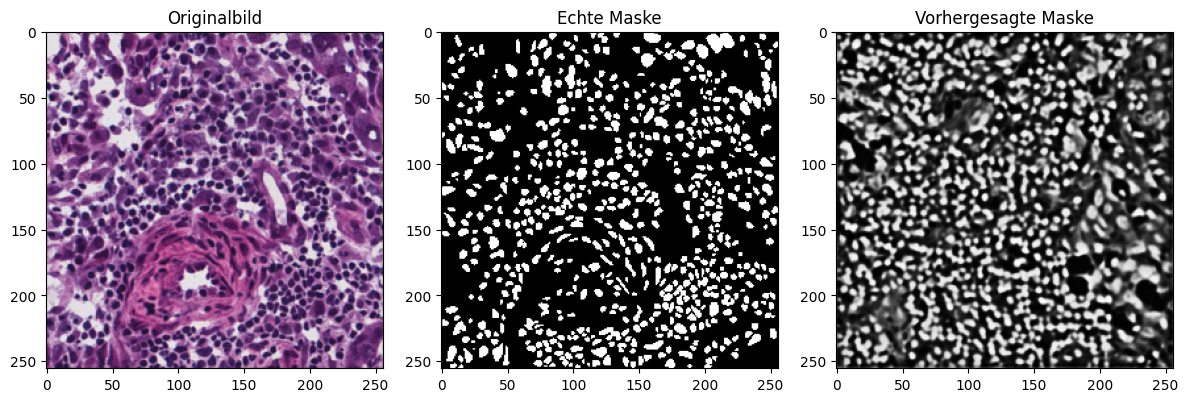

In [44]:
# Visualisierung
plt.figure(figsize=(12, 4))

# Originalbild
plt.subplot(1, 3, 1)
plt.imshow(test_images[0])
plt.title("Originalbild")

# Echte Maske
plt.subplot(1, 3, 2)
plt.imshow(test_masks[0], cmap='gray')
plt.title("Echte Maske")

# Vorhergesagte Maske
plt.subplot(1, 3, 3)
plt.imshow(pred_mask[0], cmap='gray')
plt.title("Vorhergesagte Maske")

plt.tight_layout()
plt.show()